In [54]:
#импорт библиотек
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #сплитование выборки
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Lasso
%matplotlib inline
plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Итак, набор данных содержит следующие столбцы:
1. age — возраст страхователя;
2. sex — пол;
3. bmi — индекс массы тела (), в идеале — от 18.5 до 24.9;
4. children — количество детей, охваченных медицинской страховкой;
5. smoker — является ли человек курящим;
6. region — район проживания в США (северо­восток, юго­восток, северо­запад, юго­запад);
7. charges (целевой признак) — индивидуальные медицинские расходы, оплачиваемые медицинской страховкой.

In [5]:
print(data.shape)

(1338, 7)


In [6]:
display(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

smoker — переведём в бинарные значения (0 — некурящий, 1 — курящий);

sex — аналогично (0 — female, 1 — male);

region — используем OneHot­кодирование (воспользуемся функцией get_dummies).

In [7]:
#кодируем бинарные категориальные признаки
data['smoker'] = data['smoker'].apply(lambda x: 0 if x == 'no' else 1)
data['sex'] = data['sex'].apply(lambda x: 0 if x == 'female' else 1)
#оставшиеся категориальные признаки кодируем с помощью OneHot
data = pd.get_dummies(data)
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [8]:
features = data.drop('charges', axis=1).columns
X, y = data[features], data['charges']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=42)

In [40]:
print("Размер X_test:", X_test.shape)
print("Размер y_test:", y_test.shape)

Размер X_test: (335, 9)
Размер y_test: (335,)


Количество наблюдений в тестовом наборе данных: 335

Аналитический метод. LinearRegression

In [14]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
intercept = round(model.intercept_, 2)
print("Свободный член (intercept):", intercept)

Свободный член (intercept): -12637.65


In [22]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [33]:
r2_train = round(metrics.r2_score(y_train, y_pred_train), 3)
mae_train = round(metrics.mean_absolute_error(y_train, y_pred_train))
mape_train = round(metrics.mean_absolute_percentage_error(y_train, y_pred_train) * 100)

print('Метрики для тренировочной модели')

print(f'R^2: {r2_train}')
print(f'MAE: {mae_train}')
print(f'MAPE: {mape_train} %')

Метрики для тренировочной модели
R^2: 0.745
MAE: 4183
MAPE: 42 %


In [36]:
r2_test = round(metrics.r2_score(y_test, y_pred_test), 3)
mae_test = round(metrics.mean_absolute_error(y_test, y_pred_test))
mape_test = round(metrics.mean_absolute_percentage_error(y_test, y_pred_test) * 100)

print('Метрики для тестовой модели')

print(f'R^2: {r2_test}')
print(f'MAE: {mae_test}')
print(f'MAPE: {mape_test} %')

Метрики для тестовой модели
R^2: 0.767
MAE: 4244
MAPE: 44 %


Рассчет ошибок

In [62]:
train_errors = np.ravel(y_train - y_train_pred)
test_errors = np.ravel(y_test - y_test_pred)

Визуализация ошибок линейной регрессии на тренировочной и тестовой выборках

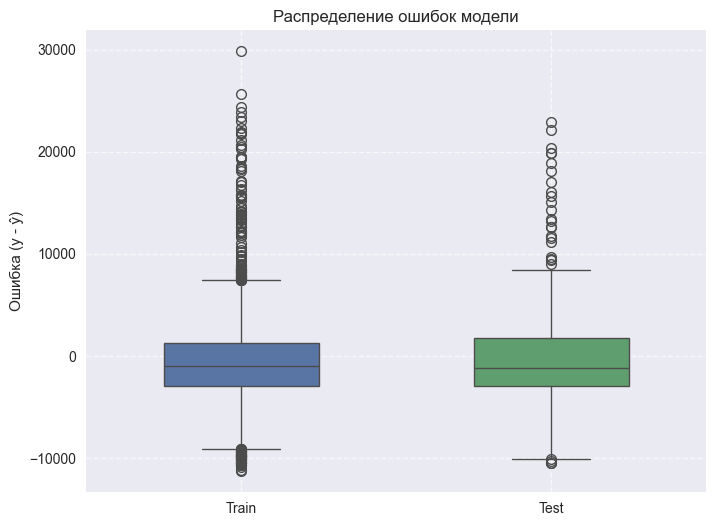

In [63]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=[train_errors, test_errors], width=0.5)

# Настройки графика
plt.xticks(ticks=[0, 1], labels=['Train', 'Test'])
plt.ylabel('Ошибка (y - ŷ)')
plt.title('Распределение ошибок модели')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Верные ответы из представленных в лабораторной работе: A и C.

In [45]:
scaler = MinMaxScaler()

In [47]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)

X_test_poly = poly.transform(X_test_scaled)

In [48]:
print("Размер X_train после преобразования:", X_train_poly.shape)
print("Размер X_test после преобразования:", X_test_poly.shape)

Размер X_train после преобразования: (1003, 54)
Размер X_test после преобразования: (335, 54)


Результирующее кол-во столбцов равно 54

Теперь обучаем модель на полиномальных признаках

In [50]:
poly_model = linear_model.LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_test_pred_poly = poly_model.predict(X_test_poly)

In [52]:
r2_poly = round(metrics.r2_score(y_test, y_test_pred_poly), 3)
print("R^2 на тестовой выборке:", r2_poly)

R^2 на тестовой выборке: 0.854


In [53]:
coefficients = poly_model.coef_
intercept = poly_model.intercept_

print("\nСвободный член (intercept):", round(intercept, 2))
print("\nКоэффициенты модели:")
print(coefficients)


Свободный член (intercept): 2312.23

Коэффициенты модели:
[  2594.07623313   -427.23203355   5698.46230027   3848.16734126
   1193.76779518    354.57964079   -334.71804684     59.43715068
    -79.29874462   8241.48715643    626.56367457   2683.15769813
  -1040.62601742     88.17324085   -813.59457068    394.01617634
   1147.35344331   1866.30118416   -427.23203355   1176.36497324
  -1365.2067131     222.04475602  -1064.28438106    452.9312142
    685.33877198   -501.21763866 -10764.28449304   2779.56578756
  54775.47121726   3793.42902024   2349.00521795   -325.06769934
   -118.90423858  -1579.54227946  -2271.64088618   2080.09438091
   1847.51810668    880.29897741   -959.74412374   1193.76779518
    254.35669242   -104.58658124   -511.1401304    1555.1378144
    354.57964079      0.              0.              0.
   -334.71804684      0.              0.             59.43715068
      0.            -79.29874462]


Из значений коэффициентов можно сделать вывод, что некоторые коэффициенты имеют экстремально высокие значения (например, 54775.47, 8241.48, -10764.28). Это может указывать на переобучение (модель слишком подстроилась под тренировочные данные, включая шумы и выбросы). Коэффициенты варьируются от -10764.28 до +54775.47, что свидетельствует о неустойчивости модели. Некоторые коэффициенты равны нулю (например, 0. в конце списка), что может означать, что есть лишние признаки (можно удалить).

Построем линейную регрессию с L1-регуляризацией.

In [56]:
lasso_model = Lasso(alpha=1.0, max_iter=2000)
lasso_model.fit(X_train_poly, y_train)

y_test_pred_lasso = lasso_model.predict(X_test_poly)

In [58]:
r2_lasso = round(metrics.r2_score(y_test, y_test_pred_lasso), 3)
mae_lasso = round(metrics.mean_absolute_error(y_test, y_test_pred_lasso))
mape_lasso = round(metrics.mean_absolute_percentage_error(y_test, y_test_pred_lasso) * 100)

print("Метрики Lasso-регрессии на тестовой выборке:")

print("R^2:", r2_lasso)
print("MAE:", mae_lasso)
print("MAPE (%):", mape_lasso)

Метрики Lasso-регрессии на тестовой выборке:
R^2: 0.854
MAE: 2779
MAPE (%): 29
